In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.base import BaseEstimator, TransformerMixin, ClassifierMixin
from sklearn.metrics import silhouette_score, confusion_matrix, ConfusionMatrixDisplay
from tqdm import tqdm
from typing import Optional
from sklearn.model_selection import cross_validate, cross_val_predict
from sklearn.inspection import permutation_importance
from sklearn.metrics import root_mean_squared_error
pd.set_option('display.max_columns', None)

In [3]:
train = pd.read_csv("train_earth.csv")
test = pd.read_csv("test_earth.csv")
train_gap = pd.read_csv("Gap_Train.csv")
test_gap = pd.read_csv("Gap_Test.csv")
variables = pd.read_csv("VariableDefinitions.csv")

In [4]:
soil_depth = 20
target_columns = ['N', 'P', 'K', 'Ca', 'Mg', 'S', 'Fe', 'Mn', 'Zn', 'Cu', 'B']

In [5]:
train_dropna = train.dropna().sort_values(by="PID")
X = train_dropna.drop(columns=target_columns)
Y = train_dropna[target_columns]

In [6]:
def scale_predictions(X, Y_pred):
    scale = X['BulkDensity'].values.reshape(-1, 1) * soil_depth * 0.1
    Y_scaled = Y_pred * scale
    return Y_scaled

In [7]:

def score_predictions(estimator, X, Y_true):
    Y_pred = estimator.predict(X)
    Y_true_final = scale_predictions(X, Y_true)
    Y_pred_final = scale_predictions(X, Y_pred)
    return -root_mean_squared_error(Y_true_final, Y_pred_final)


estimator_last_score = {}


def eval_model(estimator, X, Y, n_splits=5, estimator_key=None, n_jobs=1, print_result=True):
    result = cross_validate(estimator, X, Y, cv=n_splits,
                            scoring=score_predictions, n_jobs=n_jobs)
    scores = -result['test_score']
    mean = np.mean(scores)
    median = np.median(scores)
    if print_result:
        print("mean score:", mean)
        print("median score:", np.median(scores))
        print("std:", np.std(scores))
        print("scores:  ", scores)
    estimator_key = estimator_key or id(estimator)
    if print_result:
        if not estimator_key in estimator_last_score:
            print("first evaluation")
        else:
            last_mean, last_median = estimator_last_score[estimator_key]
            if mean < last_mean:
                print("mean improved")
            elif mean > last_mean:
                print("mean degraded")
            else:
                print("same mean")

            if median < last_median:
                print("median improved")
            elif median > last_median:
                print("median degraded")
            else:
                print("same median")

    estimator_last_score[estimator_key] = (mean, median)
    return result

In [8]:
def eval_classifier(classifier, X, y, n_splits=5, n_jobs=1, print_result=True):
    result = cross_validate(classifier, X, y, cv=n_splits,
                            scoring='roc_auc_ovr', n_jobs=n_jobs)
    scores = result['test_score']
    if print_result:
        print("mean score:", np.mean(scores))
        print("median score:", np.median(scores))
        print("std:", np.std(scores))
        print("scores:  ", scores)
    return result

In [9]:
def predict(model, test):
    predictions = model.predict(test)
    predictions = scale_predictions(test, predictions)
    predictions = pd.DataFrame(
        predictions, columns=target_columns, index=test.index)
    predictions["PID"] = test["PID"]
    predictions = predictions.melt(
        id_vars=['PID'], var_name='Nutrient', value_name='Available')
    predictions = predictions.merge(right=test_gap, on=["PID", "Nutrient"])
    predictions["Gap"] = predictions["Required"] - predictions["Available"]
    predictions['ID'] = predictions['PID'] + "_" + predictions['Nutrient']
    predictions = predictions[["ID", "Gap"]]
    return predictions

In [10]:
drop_step = ("drop", FunctionTransformer(
    lambda x: x.drop(columns=["PID", "site", 'Nadir_Reflectance_Band2', 'Nadir_Reflectance_Band4', 'QA_RADSAT',
                              'SENSING_ORBIT_NUMBER', 'SR_B1', 'SR_B2', 'SR_B4', 'SR_B6', 'SolarZenith', 'ecec20',
                              'lstn', 'para', 'relativeOrbitNumber_start', 'sur_refl_b07', 'tim'])))

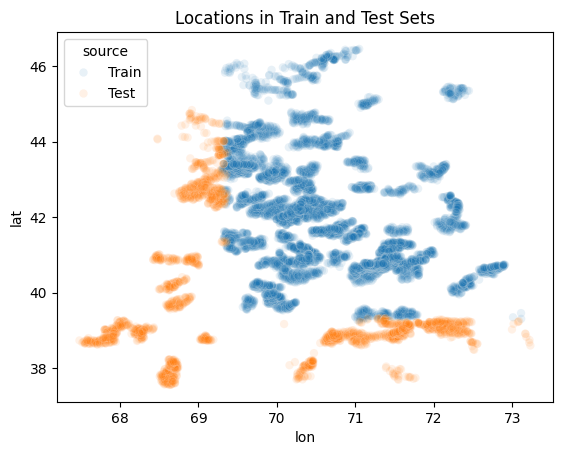

In [10]:
locations = pd.concat([
    train[['lat', 'lon']].assign(source='Train'),
    test[['lat', 'lon']].assign(source='Test')])
sns.scatterplot(x=locations['lon'],
                y=locations['lat'],
                alpha=0.1,
                hue=locations['source'])
plt.title("Locations in Train and Test Sets")
plt.show()

clustering: 100%|██████████| 11/11 [00:17<00:00,  1.63s/it]

best clustering, 2


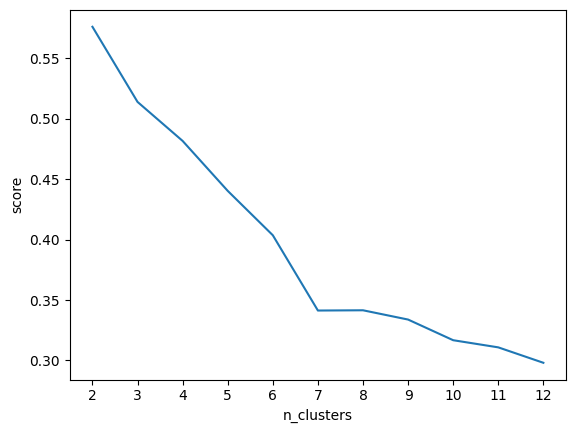

In [26]:
n_clusters_range = range(2, 13)
results = pd.DataFrame({"n_clusters": n_clusters_range, "score": None})
for i, n_clusters in enumerate(tqdm(n_clusters_range, desc="clustering")):
    kmeans = KMeans(n_clusters=n_clusters)
    target_cluster_k = kmeans.fit_predict(Y)
    results.iloc[i, 1] = silhouette_score(X=Y, labels=target_cluster_k)
sns.lineplot(x=results['n_clusters'], y=results['score'])
print(f"best clustering, {results.iloc[np.argmax(results['score']), 0]}")
plt.xticks(n_clusters_range)
plt.show()

In [12]:
kmeans = KMeans(n_clusters=2, random_state=0)
target_cluster = pd.Series(data=kmeans.fit_predict(Y), index=Y.index)
silhouette_score(X=Y, labels=target_cluster)

np.float64(0.5759108016817921)

In [13]:
max_nutrient = train_dropna[target_columns].apply(
    lambda x: np.argmax(x), axis=1).map(lambda x: target_columns[x])
max_nutrient_encoded = max_nutrient == 'Ca'
max_nutrient.value_counts()

Ca    6196
N     1539
Name: count, dtype: int64

In [1]:
column_count = len(target_columns)
nrows = (column_count + 2) // 3
ncols = min(column_count, 3)
fig, axs = plt.subplots(nrows=nrows, ncols=ncols,
                        figsize=(5*ncols, 4*nrows),
                        constrained_layout=True)
axs = axs.reshape(-1)
for i, col in enumerate(tqdm(target_columns, desc="Plotting")):
    axs[i].set_title(col)
    sns.histplot(hue=max_nutrient, x=train_dropna[col], ax=axs[i],
                 stat='density',  # Normalizes each hue group separately
                 common_norm=False,  # Each hue gets its own scale
                 kde=True, )
plt.title("Target Distribution based on Max Nutrient")
plt.show()

NameError: name 'target_columns' is not defined

In [18]:
from sklearn.ensemble import HistGradientBoostingClassifier
is_ca_max_hist = Pipeline(
    [("drop", FunctionTransformer(lambda x: x.drop(columns=["PID", "site", 'mb1', 'mdem', 'QA_PIXEL', 'VH']))),
     ("c", ColumnTransformer(
         [('log',  FunctionTransformer(np.log1p),
           ['B7', 'MEAN_SOLAR_ZENITH_ANGLE']),],
         remainder='passthrough', force_int_remainder_cols=False)),
     ("hist", HistGradientBoostingClassifier(random_state=0
                                             ))])


eval_classifier(is_ca_max_hist, X,
                max_nutrient_encoded, n_jobs=-1, n_splits=4)

mean score: 0.9642203879615112
median score: 0.9636138662284562
std: 0.00404297536112065
scores:   [0.95963713 0.97001668 0.9658548  0.96137293]


{'fit_time': array([3.34441757, 3.29986119, 3.35966659, 3.32217455]),
 'score_time': array([0.04658198, 0.04526639, 0.04217482, 0.05175281]),
 'test_score': array([0.95963713, 0.97001668, 0.9658548 , 0.96137293])}

In [19]:
from sklearn.ensemble import HistGradientBoostingClassifier
target_cluster_hist = Pipeline(
    [("drop", FunctionTransformer(lambda x: x.drop(columns=["PID", "site", 'mdem', 'QA_PIXEL']))),
     ("c", ColumnTransformer(
         [('log',  FunctionTransformer(np.log1p),
           ['B8A', 'CLOUDY_PIXEL_PERCENTAGE',
             'MEAN_SOLAR_ZENITH_ANGLE', 'NODATA_PIXEL_PERCENTAGE']),],
         remainder='passthrough', force_int_remainder_cols=False)),
     ("hist", HistGradientBoostingClassifier(random_state=0
                                             ))])
eval_classifier(target_cluster_hist, X,
                target_cluster, n_jobs=-1, n_splits=4)

mean score: 0.9644643452776609
median score: 0.9647462311005626
std: 0.002365150438074923
scores:   [0.96650157 0.96299089 0.96136329 0.96700163]


{'fit_time': array([3.52725554, 3.52740979, 3.50266695, 3.54696941]),
 'score_time': array([0.06392264, 0.06377435, 0.05950665, 0.05227828]),
 'test_score': array([0.96650157, 0.96299089, 0.96136329, 0.96700163])}

In [ ]:
classifier_columns = X.columns
is_ca_max_hist.fit(X, max_nutrient_encoded)

target_cluster_hist.fit(X, target_cluster)

Pipeline(steps=[('drop',
                 FunctionTransformer(func=<function <lambda> at 0x000001F944B8DD00>)),
                ('c',
                 ColumnTransformer(force_int_remainder_cols=False,
                                   remainder='passthrough',
                                   transformers=[('log',
                                                  FunctionTransformer(func=<ufunc 'log1p'>),
                                                  ['B8A',
                                                   'CLOUDY_PIXEL_PERCENTAGE',
                                                   'MEAN_SOLAR_ZENITH_ANGLE',
                                                   'NODATA_PIXEL_PERCENTAGE'])])),
                ('hist', HistGradientBoostingClassifier(random_state=0))])

In [21]:
def add_is_ca_max_nutrient(X: pd.DataFrame):
    X = X.copy()
    X['is_ca_max_nutrient'] = is_ca_max_hist.predict(X[classifier_columns])
    return X

In [22]:
def add_target_cluster(X: pd.DataFrame):

    X = X.copy()

    X['target_cluster'] = target_cluster_hist.predict(X[classifier_columns])

    return X

In [ ]:
from sklearn.ensemble import HistGradientBoostingRegressor


from sklearn.multioutput import MultiOutputRegressor
hist = Pipeline([('target_cluster', FunctionTransformer(add_target_cluster)),
                 ('is_ca_max_nutrient', FunctionTransformer(add_is_ca_max_nutrient)),
                 drop_step,
                 ("hist", MultiOutputRegressor(HistGradientBoostingRegressor(random_state=0,
                                                                             max_iter=350,
                                                                             learning_rate=0.1,
                                                                             loss='squared_error'),
                                               n_jobs=2))])
eval_model(hist, X, Y, n_jobs=4, n_splits=4, estimator_key="hist")

In [ ]:
from xgboost import XGBRegressor
xgb_regressor = Pipeline([('target_cluster', FunctionTransformer(add_target_cluster)),
                          ('is_ca_max_nutrient', FunctionTransformer(
                              add_is_ca_max_nutrient)),
                          drop_step,
                          ("xgb", XGBRegressor(
                              random_state=0,
                              n_estimators=300,
                              max_depth=10,
                              learning_rate=0.025,
                              subsample=0.6,
                              tree_method="hist",
                              device="cuda"),
                           )])
eval_model(xgb_regressor, X, Y, n_jobs=-1, n_splits=4, estimator_key="xgb")

In [25]:
xgb_regressor.fit(X, Y)

Pipeline(steps=[('target_cluster',
                 FunctionTransformer(func=<function add_target_cluster at 0x000001F944B8E5C0>)),
                ('is_ca_max_nutrient',
                 FunctionTransformer(func=<function add_is_ca_max_nutrient at 0x000001F944B8E160>)),
                ('drop',
                 FunctionTransformer(func=<function <lambda> at 0x000001F9439DCD60>)),
                ('xgb',
                 XGBRegressor(base_score=None, booster=None, callbacks=None,...
                              feature_types=None, feature_weights=None,
                              gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=0.025,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=10, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, multi_strategy=None,
                              n_estimators=300, n_jobs=None,
                              num_parallel_tree=None, ...))])

In [26]:
predictions = predict(xgb_regressor, test)
predictions.to_csv("submissions/xgb_submission.csv", index=False)
predictions.head()

c:\Users\Omer\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\core.py:729: UserWarning: [02:52:32] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:58: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


,ID,Gap
0,ID_NGS9Bx_N,-2759.629883
1,ID_YdVKXw_N,-2691.556055
2,ID_MZAlfE_N,-3127.128418
3,ID_GwCCMN_N,-3196.778359
4,ID_K8sowf_N,-3440.798838


In [27]:
hist.fit(X, Y)

Pipeline(steps=[('target_cluster',
                 FunctionTransformer(func=<function add_target_cluster at 0x000001F944B8E5C0>)),
                ('is_ca_max_nutrient',
                 FunctionTransformer(func=<function add_is_ca_max_nutrient at 0x000001F944B8E160>)),
                ('drop',
                 FunctionTransformer(func=<function <lambda> at 0x000001F9439DCD60>)),
                ('hist',
                 MultiOutputRegressor(estimator=HistGradientBoostingRegressor(max_iter=350,
                                                                              random_state=0),
                                      n_jobs=2))])

In [28]:
predictions = predict(hist, test)
predictions.to_csv("submissions/hist_submission.csv", index=False)
predictions.head()

,ID,Gap
0,ID_NGS9Bx_N,-3114.918987
1,ID_YdVKXw_N,-2848.610795
2,ID_MZAlfE_N,-2949.872783
3,ID_GwCCMN_N,-3844.605911
4,ID_K8sowf_N,-3300.142351
